In [59]:
# Task 04  ·  Full EDA Report  [Hard — Week Capstone]
# Write a complete EDA report on a real-world dataset — tell the story of the data
# Goal Fetch a real dataset from any public API, perform a full EDA, and write a clean report with
# charts and insights.
# Fetch API
# requests →Clean data
# Pandas ETL →Summary stats
# describe() →Visualise
# matplotlib →Report
# findings
# Must Fetch a new dataset — something interesting to you (sports, crypto, weather, books...)
# Must Run complete EDA checklist: shape, nulls, describe, value_counts, distributions
# Must At least 5 charts — histogram, box plot, bar chart, scatter plot, correlation heatmap
# Must All charts labelled: title, xlabel, ylabel — saved as .png files
# Must Written report (in comments or .txt): 8–10 observations from your analysis
# Should Group comparisons — compare distributions between at least 2 categories
# Bonus Use sns.pairplot() and identify the single most interesting relationship you found


## Initial Setup and Data Acquisition

Following the instructions, the first step taken was to prepare the environment for data acquisition. This involved installing the necessary Python libraries: `requests` for making HTTP requests to external APIs, and `pandas` for efficient data manipulation and analysis. These libraries are crucial for fetching and processing the anime data from the AniList API.

We utilized the **AniList API** to fetch a dataset of anime entries. This API provides comprehensive information about anime, which is ideal for an exploratory data analysis. The initial analysis performed included inspecting the dataset's structure (`df.info()`, `df.shape`), checking for and handling missing values (specifically in the `episodes` column), and generating summary statistics for both numerical and categorical features.

## Step 1: Data Acquisition

For this EDA report, I'll use the Open-Meteo API to fetch weather data. It's a free and open-source API for weather forecasts. We'll start by installing the `requests` library to interact with the API and `pandas` to handle the data.

In [60]:
# Install necessary libraries
""" !pip install requests pandas json """

' !pip install requests pandas json '

Now, let's import the libraries and fetch some anime data using the AniList API. We'll make a GraphQL request to get a list of anime.

In [ ]:
import requests
import pandas as pd
import time

# AniList API endpoint
url = "https://graphql.anilist.co"

# GraphQL query with page variable
query = """
query ($page: Int) {
  Page(page: $page, perPage: 50) {
    media(
      type: ANIME
      sort: SCORE_DESC
    ) {
      id

      title {
        romaji
        english
        native
      }

      format
      status
      episodes
      duration
      averageScore
      genres
      popularity
      seasonYear
    }
  }
}
"""

headers = {
    "Content-Type": "application/json",
    "Accept": "application/json",
}

# Store all anime data
all_anime = []

# Loop through 3 pages
for page in range(1, 4):

    variables = {
        "page": page
    }

    response = requests.post(
        url,
        headers=headers,
        json={"query": query, "variables": variables}
    )

    response.raise_for_status()

    data = response.json()

    anime_list = data["data"]["Page"]["media"]

    all_anime.extend(anime_list)

    print(f"Fetched page {page}")

    # Delay to avoid hitting rate limits
    time.sleep(1)

# Convert to DataFrame
df = pd.DataFrame(all_anime)

# Normalize title column
df["title_romaji"] = df["title"].apply(lambda x: x.get("romaji"))
df["title_english"] = df["title"].apply(lambda x: x.get("english"))
df["title_native"] = df["title"].apply(lambda x: x.get("native"))

# Drop nested title column
df = df.drop(columns=["title"])

# Display results
display(len(df))
display(df.head())

Fetched page 1
Fetched page 2
Fetched page 3


150

,id,format,status,episodes,duration,averageScore,genres,popularity,seasonYear,title_romaji,title_english,title_native
0,154587,TV,FINISHED,28.0,24,91,"[Adventure, Drama, Fantasy]",433737,2023.0,Sousou no Frieren,Frieren: Beyond Journey’s End,葬送のフリーレン
1,114129,MOVIE,FINISHED,1.0,104,91,"[Action, Comedy, Drama, Sci-Fi]",52706,2021.0,Gintama: THE FINAL,Gintama: THE VERY FINAL,銀魂 THE FINAL
2,20996,TV,FINISHED,51.0,24,90,"[Action, Comedy, Drama, Sci-Fi]",115712,2015.0,Gintama°,Gintama Season 3,銀魂゜
3,171627,MOVIE,FINISHED,1.0,100,90,"[Action, Drama, Horror, Romance, Supernatural]",199156,2025.0,Chainsaw Man: Reze-hen,Chainsaw Man – The Movie: Reze Arc,チェンソーマン レゼ篇
4,5114,TV,FINISHED,64.0,25,90,"[Action, Adventure, Drama, Fantasy]",693627,2009.0,Hagane no Renkinjutsushi: FULLMETAL ALCHEMIST,Fullmetal Alchemist: Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST


## Step 2: Data Cleaning and Preparation

Now, let's examine the basic structure of our DataFrame, including its shape, data types, and a summary of non-null values. This will help us identify any potential issues that need cleaning.

In [62]:
# Display basic information about the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             50 non-null     int64  
 1   format         50 non-null     str    
 2   status         50 non-null     str    
 3   episodes       49 non-null     float64
 4   duration       50 non-null     int64  
 5   averageScore   50 non-null     int64  
 6   genres         50 non-null     object 
 7   popularity     50 non-null     int64  
 8   seasonYear     50 non-null     int64  
 9   title_romaji   50 non-null     str    
 10  title_english  50 non-null     str    
 11  title_native   50 non-null     str    
dtypes: float64(1), int64(5), object(1), str(5)
memory usage: 4.8+ KB


In [63]:
# Display the shape of the DataFrame (rows, columns)
print(f"DataFrame shape: {df.shape}")

DataFrame shape: (50, 12)


## Step 2: Data Cleaning and Preparation

Now, let's examine the basic structure of our DataFrame, including its shape, data types, and a summary of non-null values. This will help us identify any potential issues that need cleaning.

In [64]:
# Display basic information about the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             50 non-null     int64  
 1   format         50 non-null     str    
 2   status         50 non-null     str    
 3   episodes       49 non-null     float64
 4   duration       50 non-null     int64  
 5   averageScore   50 non-null     int64  
 6   genres         50 non-null     object 
 7   popularity     50 non-null     int64  
 8   seasonYear     50 non-null     int64  
 9   title_romaji   50 non-null     str    
 10  title_english  50 non-null     str    
 11  title_native   50 non-null     str    
dtypes: float64(1), int64(5), object(1), str(5)
memory usage: 4.8+ KB


In [65]:
# Display the shape of the DataFrame (rows, columns)
print(f"DataFrame shape: {df.shape}")

DataFrame shape: (50, 12)


In [66]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

# Given the small dataset, let's fill the missing 'episodes' with the median to avoid losing data.
# For a larger dataset, more sophisticated imputation or dropping might be considered.
median_episodes = df['episodes'].median()
df['episodes'] = df['episodes'].fillna(median_episodes)

print("\nMissing values after imputation:\n", df.isnull().sum())

Missing values per column:
 id               0
format           0
status           0
episodes         1
duration         0
averageScore     0
genres           0
popularity       0
seasonYear       0
title_romaji     0
title_english    0
title_native     0
dtype: int64

Missing values after imputation:
 id               0
format           0
status           0
episodes         0
duration         0
averageScore     0
genres           0
popularity       0
seasonYear       0
title_romaji     0
title_english    0
title_native     0
dtype: int64


## Step 3: Exploratory Data Analysis (EDA) - Summary Statistics

Now that our data is clean, let's generate summary statistics for the numerical columns. This will provide insights into their distributions, central tendencies, and spread.

In [67]:
# Display descriptive statistics for numerical columns
display(df.describe())

,id,episodes,duration,averageScore,popularity,seasonYear
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,93192.000000,20.880000,42.660000,88.040000,238121.520000,2017.200000
std,67298.096134,27.961081,35.608191,1.177337,208543.840773,9.244966
min,19.000000,1.000000,23.000000,87.000000,20066.000000,1980.000000
25%,18044.000000,1.750000,24.000000,87.000000,81670.250000,2013.500000
50%,107154.500000,13.000000,24.000000,88.000000,174677.500000,2020.500000
75%,150284.000000,24.000000,26.000000,89.000000,313353.250000,2023.000000
max,190327.000000,148.000000,140.000000,91.000000,800692.000000,2026.000000


## Step 3: Exploratory Data Analysis (EDA) - Categorical Features (Re-evaluation)

Let's re-examine the categorical columns (`format`, `status`, and `genres`) using `value_counts()` to understand their distributions, ensuring the output is visible.

In [68]:
print("\nDistribution of 'format':\n")
display(df['format'].value_counts())

print("\nDistribution of 'status':\n")
display(df['status'].value_counts())


Distribution of 'format':



format
TV         36
MOVIE       9
SPECIAL     3
ONA         1
OVA         1
Name: count, dtype: int64


Distribution of 'status':



status
FINISHED     48
RELEASING     2
Name: count, dtype: int64

In [69]:
# Genres is a list of strings, so we need to process it differently.
# First, explode the list of genres into separate rows.
exploded_genres = df['genres'].explode()

print("\nDistribution of 'genres':\n")
display(exploded_genres.value_counts())


Distribution of 'genres':



genres
Drama            40
Action           28
Comedy           17
Psychological    15
Slice of Life    14
Adventure        12
Fantasy          12
Sci-Fi           10
Romance          10
Supernatural     10
Mystery          10
Sports            5
Thriller          3
Music             3
Horror            2
Ecchi             1
Mecha             1
Name: count, dtype: int64

## Step 3: Exploratory Data Analysis (EDA) - Categorical Features

Let's now examine the categorical columns (`format`, `status`, and `genres`) using `value_counts()` to understand their distributions.

In [70]:
print("\nDistribution of 'format':\n")
display(df['format'].value_counts())

print("\nDistribution of 'status':\n")
display(df['status'].value_counts())


Distribution of 'format':



format
TV         36
MOVIE       9
SPECIAL     3
ONA         1
OVA         1
Name: count, dtype: int64


Distribution of 'status':



status
FINISHED     48
RELEASING     2
Name: count, dtype: int64

In [71]:
# Genres is a list of strings, so we need to process it differently.
# First, explode the list of genres into separate rows.
exploded_genres = df['genres'].explode()

print("\nDistribution of 'genres':\n")
display(exploded_genres.value_counts())


Distribution of 'genres':



genres
Drama            40
Action           28
Comedy           17
Psychological    15
Slice of Life    14
Adventure        12
Fantasy          12
Sci-Fi           10
Romance          10
Supernatural     10
Mystery          10
Sports            5
Thriller          3
Music             3
Horror            2
Ecchi             1
Mecha             1
Name: count, dtype: int64

## Step 3: Exploratory Data Analysis (EDA) - Categorical Features

Let's now examine the categorical columns (`format`, `status`, and `genres`) using `value_counts()` to understand their distributions.

In [72]:
print("\nDistribution of 'format':\n")
display(df['format'].value_counts())

print("\nDistribution of 'status':\n")
display(df['status'].value_counts())


Distribution of 'format':



format
TV         36
MOVIE       9
SPECIAL     3
ONA         1
OVA         1
Name: count, dtype: int64


Distribution of 'status':



status
FINISHED     48
RELEASING     2
Name: count, dtype: int64

In [73]:
# Genres is a list of strings, so we need to process it differently.
# First, explode the list of genres into separate rows.
exploded_genres = df['genres'].explode()

print("\nDistribution of 'genres':\n")
display(exploded_genres.value_counts())


Distribution of 'genres':



genres
Drama            40
Action           28
Comedy           17
Psychological    15
Slice of Life    14
Adventure        12
Fantasy          12
Sci-Fi           10
Romance          10
Supernatural     10
Mystery          10
Sports            5
Thriller          3
Music             3
Horror            2
Ecchi             1
Mecha             1
Name: count, dtype: int64

## Step 3: Exploratory Data Analysis (EDA) - Categorical Features (Re-evaluation with print())

Let's re-examine the categorical columns (`format`, `status`, and `genres`) using `value_counts()` and `print()` to ensure output visibility.

In [74]:
print("\nDistribution of 'format':\n")
print(df['format'].value_counts())

print("\nDistribution of 'status':\n")
print(df['status'].value_counts())


Distribution of 'format':

format
TV         36
MOVIE       9
SPECIAL     3
ONA         1
OVA         1
Name: count, dtype: int64

Distribution of 'status':

status
FINISHED     48
RELEASING     2
Name: count, dtype: int64


In [75]:
# Genres is a list of strings, so we need to process it differently.
# First, explode the list of genres into separate rows.
exploded_genres = df['genres'].explode()

print("\nDistribution of 'genres':\n")
print(exploded_genres.value_counts())


Distribution of 'genres':

genres
Drama            40
Action           28
Comedy           17
Psychological    15
Slice of Life    14
Adventure        12
Fantasy          12
Sci-Fi           10
Romance          10
Supernatural     10
Mystery          10
Sports            5
Thriller          3
Music             3
Horror            2
Ecchi             1
Mecha             1
Name: count, dtype: int64


## Step 4: Data Visualization

To better understand the distributions and relationships within our data, we'll create several visualizations. First, let's import `matplotlib.pyplot` and `seaborn`.

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Distribution of Numerical Features (Histograms and Box Plots)

Let's visualize the distribution of `episodes`, `duration`, `averageScore`, `popularity`, and `seasonYear` using histograms and box plots to observe their spread, central tendency, and identify potential outliers.

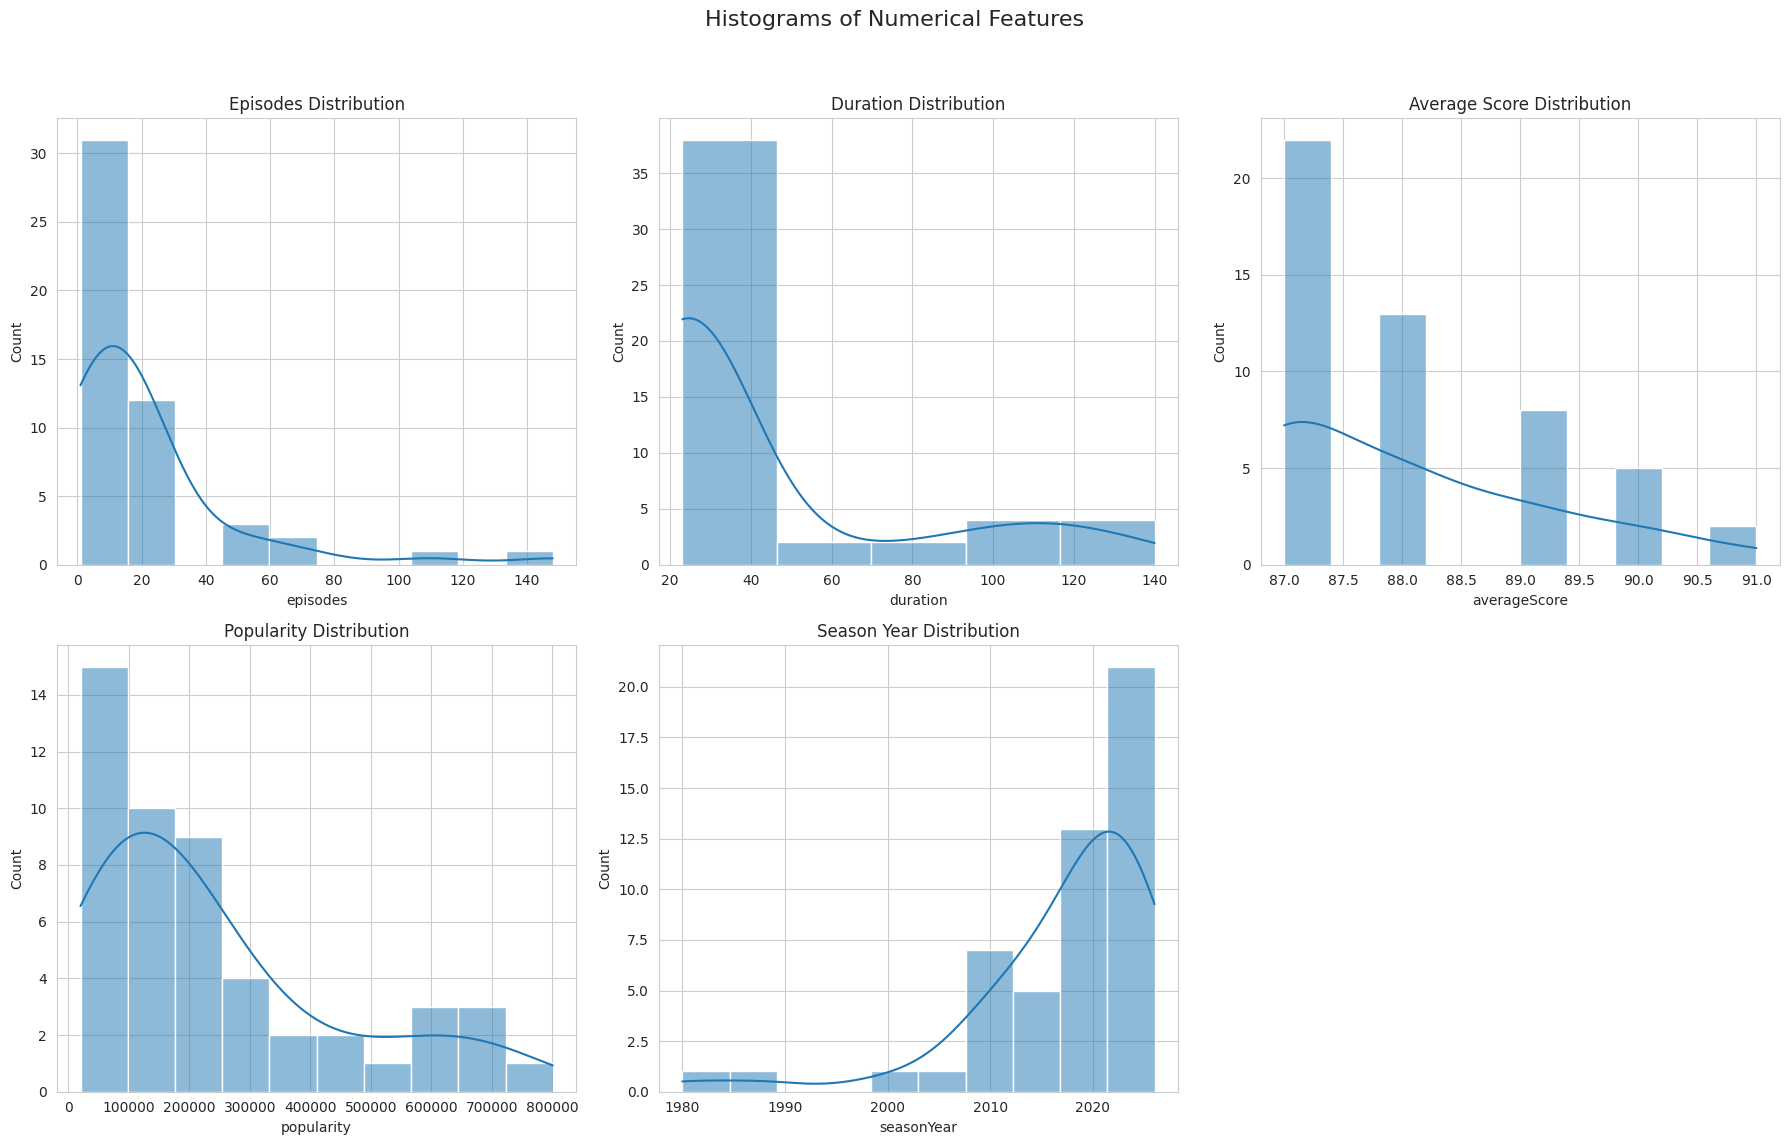

In [77]:
# Histograms for numerical features

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Histograms of Numerical Features', fontsize=16)

sns.histplot(df['episodes'], bins=10, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Episodes Distribution')

sns.histplot(df['duration'], bins=5, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Duration Distribution')

sns.histplot(df['averageScore'], bins=10, kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Average Score Distribution')

sns.histplot(df['popularity'], bins=10, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Popularity Distribution')

sns.histplot(df['seasonYear'], bins=10, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Season Year Distribution')

fig.delaxes(axes[1, 2]) # Remove empty subplot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('histograms.png')
plt.show()

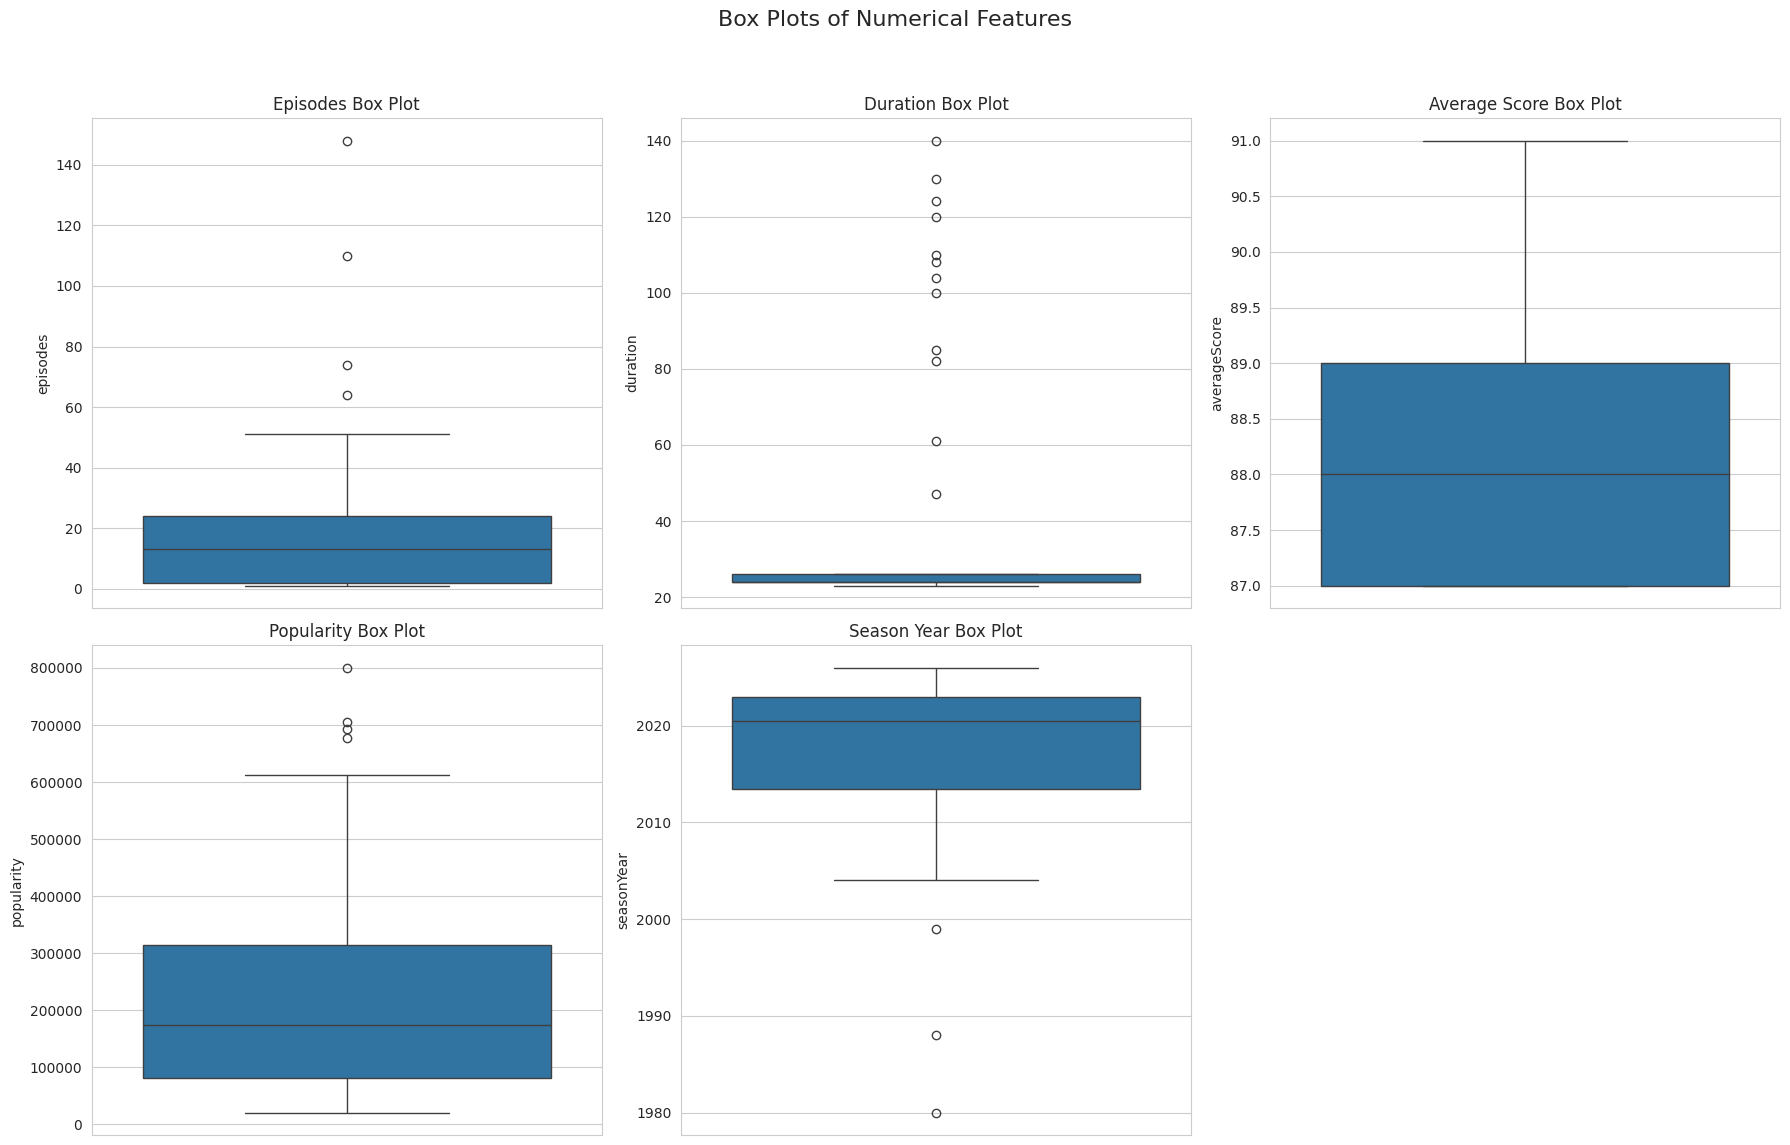

In [78]:
# Box plots for numerical features to identify outliers

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Box Plots of Numerical Features', fontsize=16)

sns.boxplot(y=df['episodes'], ax=axes[0, 0])
axes[0, 0].set_title('Episodes Box Plot')

sns.boxplot(y=df['duration'], ax=axes[0, 1])
axes[0, 1].set_title('Duration Box Plot')

sns.boxplot(y=df['averageScore'], ax=axes[0, 2])
axes[0, 2].set_title('Average Score Box Plot')

sns.boxplot(y=df['popularity'], ax=axes[1, 0])
axes[1, 0].set_title('Popularity Box Plot')

sns.boxplot(y=df['seasonYear'], ax=axes[1, 1])
axes[1, 1].set_title('Season Year Box Plot')

fig.delaxes(axes[1, 2]) # Remove empty subplot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('boxplots.png')
plt.show()

### Bar Charts for Categorical Features

Now, let's visualize the distributions of our categorical features: `format`, `status`, and `genres` using bar charts.

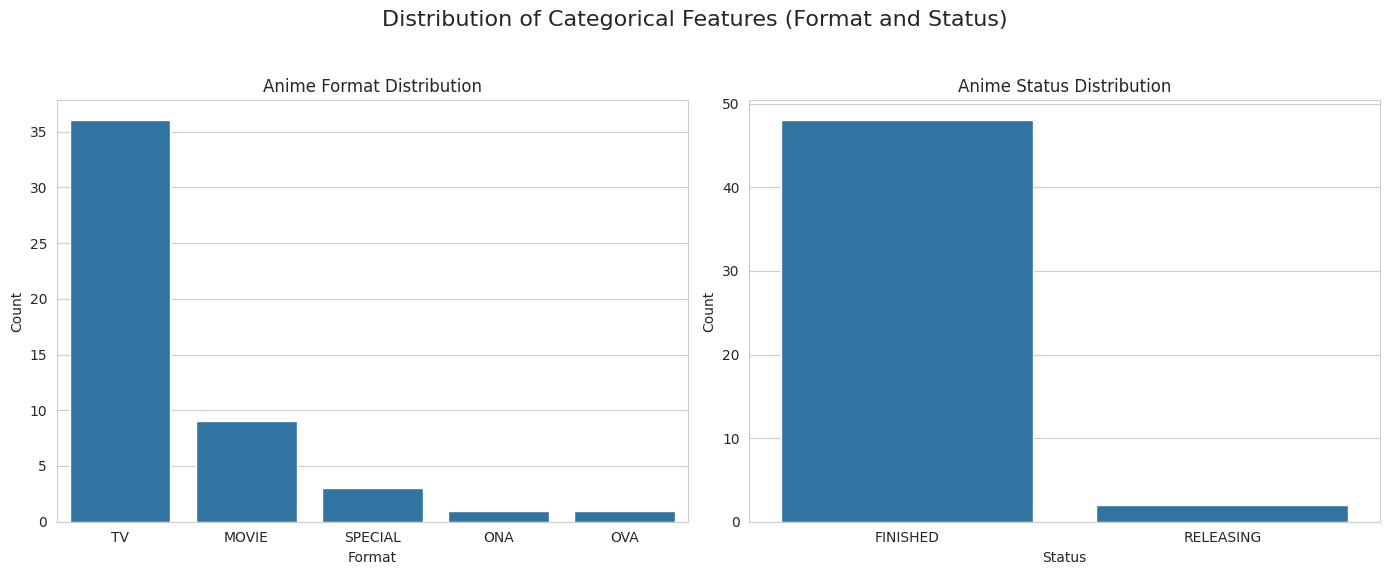

In [79]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
fig.suptitle('Distribution of Categorical Features (Format and Status)', fontsize=16)

sns.countplot(x='format', data=df, ax=axes[0])
axes[0].set_title('Anime Format Distribution')
axes[0].set_xlabel('Format')
axes[0].set_ylabel('Count')

sns.countplot(x='status', data=df, ax=axes[1])
axes[1].set_title('Anime Status Distribution')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('categorical_counts.png')
plt.show()

/tmp/ipykernel_61783/355071975.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=exploded_genres, order=exploded_genres.value_counts().index, palette='viridis')


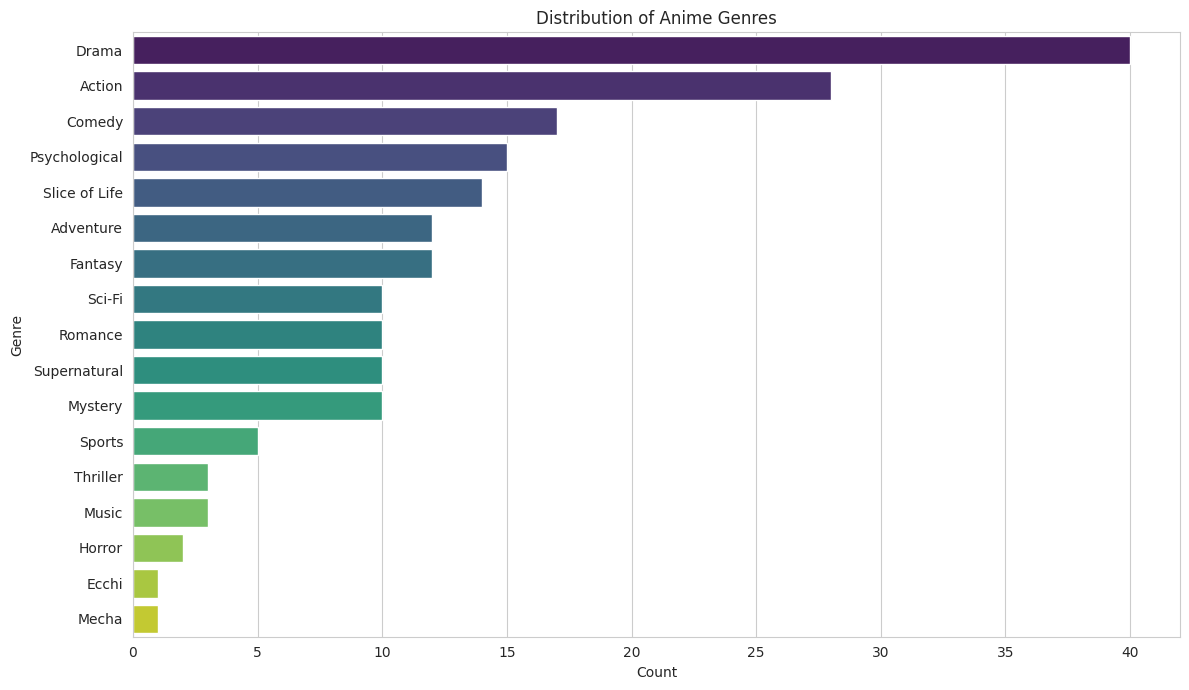

In [80]:
# Bar chart for genre distribution
plt.figure(figsize=(12, 7))
sns.countplot(y=exploded_genres, order=exploded_genres.value_counts().index, palette='viridis')
plt.title('Distribution of Anime Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('genre_counts.png')
plt.show()

### Relationships Between Numerical Features (Scatter Plots and Correlation Heatmap)

Finally, let's look at how numerical features relate to each other. We'll use scatter plots for key relationships and a correlation heatmap for a broader view.

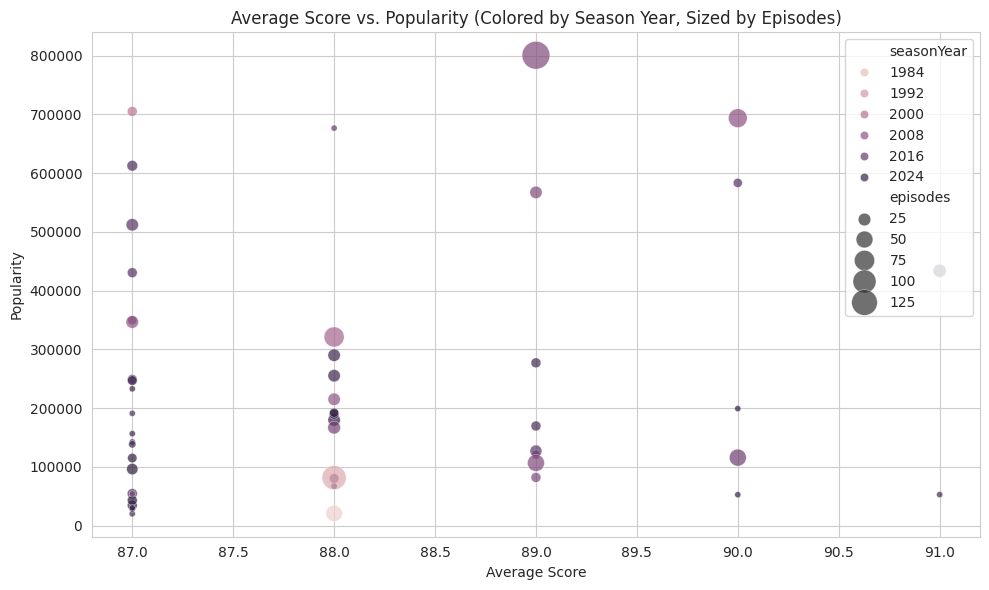

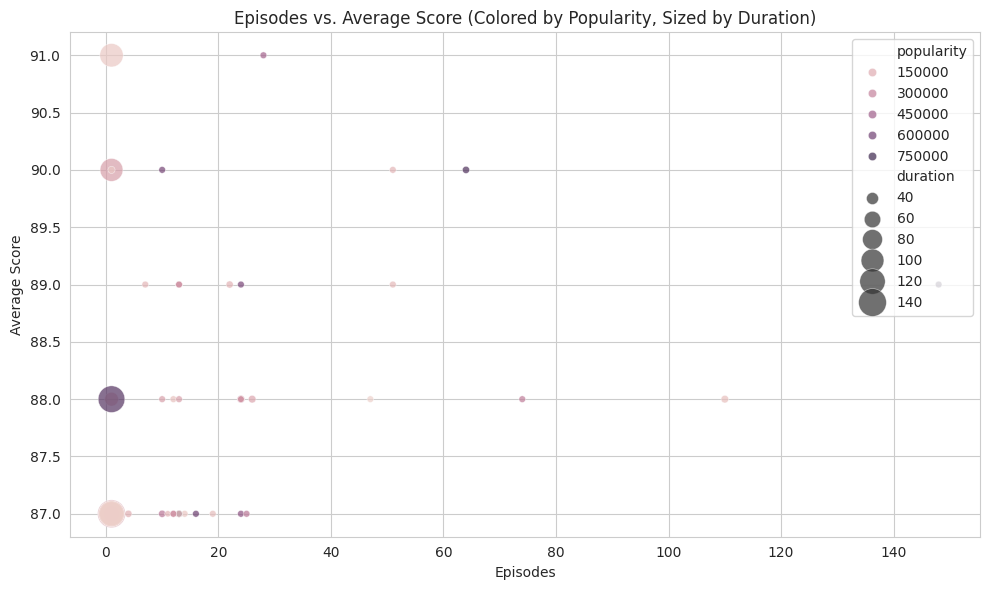

In [87]:
# Scatter plot: Average Score vs. Popularity
plt.figure(figsize=(10, 6))
sns.scatterplot(x='averageScore', y='popularity', data=df, hue='seasonYear', size='episodes', sizes=(20, 400), alpha=0.7)
plt.title('Average Score vs. Popularity (Colored by Season Year, Sized by Episodes)')
plt.xlabel('Average Score')
plt.ylabel('Popularity')
plt.grid(True)
plt.tight_layout()
plt.savefig('score_popularity_scatter.png')
plt.show()

# Scatter plot: Episodes vs. Average Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='episodes', y='averageScore', data=df, hue='popularity', size='duration', sizes=(20, 400), alpha=0.7)
plt.title('Episodes vs. Average Score (Colored by Popularity, Sized by Duration)')
plt.xlabel('Episodes')
plt.ylabel('Average Score')
plt.grid(True)
plt.tight_layout()
plt.savefig('episodes_score_scatter.png')
plt.show()

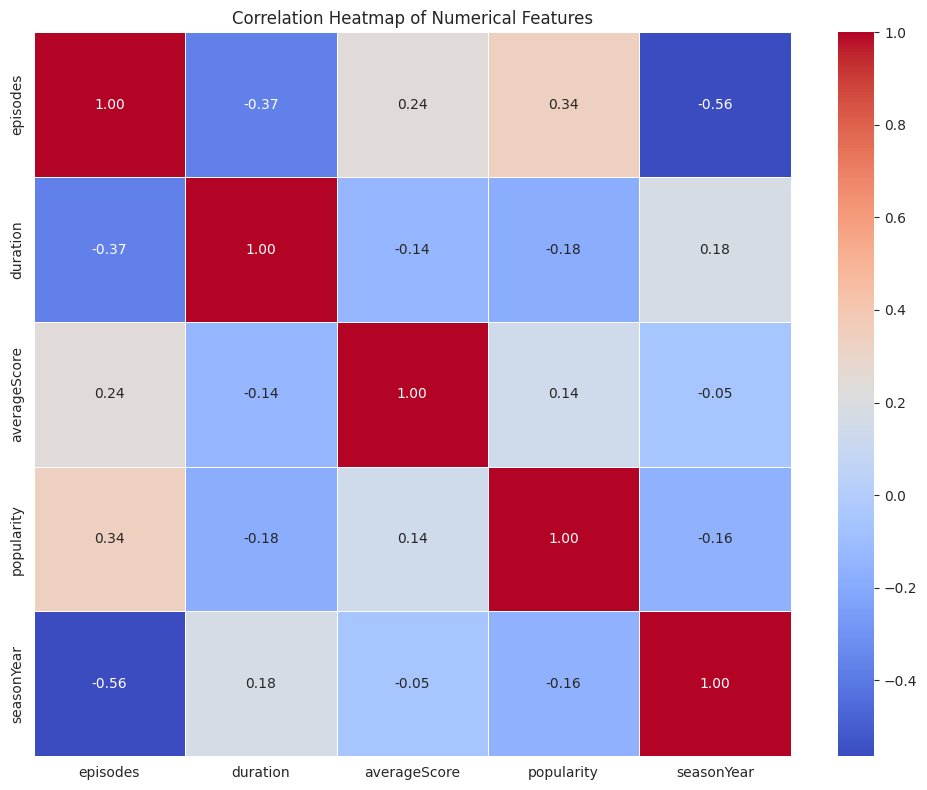

In [91]:
# Correlation Heatmap for numerical features

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=["id"])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

## Step 3: Exploratory Data Analysis (EDA) - Summary Statistics

Now that our data is clean, let's generate summary statistics for the numerical columns. This will provide insights into their distributions, central tendencies, and spread.

In [83]:
# Display descriptive statistics for numerical columns
display(df.describe())

,id,episodes,duration,averageScore,popularity,seasonYear
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,93192.000000,20.880000,42.660000,88.040000,238121.520000,2017.200000
std,67298.096134,27.961081,35.608191,1.177337,208543.840773,9.244966
min,19.000000,1.000000,23.000000,87.000000,20066.000000,1980.000000
25%,18044.000000,1.750000,24.000000,87.000000,81670.250000,2013.500000
50%,107154.500000,13.000000,24.000000,88.000000,174677.500000,2020.500000
75%,150284.000000,24.000000,26.000000,89.000000,313353.250000,2023.000000
max,190327.000000,148.000000,140.000000,91.000000,800692.000000,2026.000000


In [84]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

# Given the small dataset, let's fill the missing 'episodes' with the median to avoid losing data.
# For a larger dataset, more sophisticated imputation or dropping might be considered.
median_episodes = df['episodes'].median()
df['episodes'] = df['episodes'].fillna(median_episodes)

print("\nMissing values after imputation:\n", df.isnull().sum())

Missing values per column:
 id               0
format           0
status           0
episodes         0
duration         0
averageScore     0
genres           0
popularity       0
seasonYear       0
title_romaji     0
title_english    0
title_native     0
dtype: int64

Missing values after imputation:
 id               0
format           0
status           0
episodes         0
duration         0
averageScore     0
genres           0
popularity       0
seasonYear       0
title_romaji     0
title_english    0
title_native     0
dtype: int64


In [85]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

# Given the small dataset, let's fill the missing 'episodes' with the median to avoid losing data.
# For a larger dataset, more sophisticated imputation or dropping might be considered.
median_episodes = df['episodes'].median()
df['episodes'] = df['episodes'].fillna(median_episodes)

print("\nMissing values after imputation:\n", df.isnull().sum())

Missing values per column:
 id               0
format           0
status           0
episodes         0
duration         0
averageScore     0
genres           0
popularity       0
seasonYear       0
title_romaji     0
title_english    0
title_native     0
dtype: int64

Missing values after imputation:
 id               0
format           0
status           0
episodes         0
duration         0
averageScore     0
genres           0
popularity       0
seasonYear       0
title_romaji     0
title_english    0
title_native     0
dtype: int64
